In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

In [2]:
def mixed_walk(n_particles=100, n_steps=50, frac_det=0.5, det_step_range=(0.1, 1.0), rand_std=0.5, seed=None):
    """
    Generate a 1D walk for each particle where a fraction of steps are deterministic
    and the remaining fraction are random. Returns net displacement and path length arrays.

    Parameters:
        n_particles : int
            Number of particles.
        n_steps : int
            Total number of steps per particle.
        frac_det : float
            Fraction of steps that are deterministic (0-1).
        det_step_range : tuple
            Min and max deterministic step size.
        rand_std : float
            Standard deviation of random steps.
        seed : int or None
            Random seed for reproducibility.

    Returns:
        net : np.ndarray
            Net displacement for each particle.
        path : np.ndarray
            Total path length for each particle.
    """
    if seed is not None:
        np.random.seed(seed)

    # --- Initial positions ---
    x_init = np.random.uniform(-10, 10, n_particles)

    # --- Deterministic steps for each particle ---
    deterministic_steps = np.random.uniform(det_step_range[0], det_step_range[1], n_particles)

    # --- Number of deterministic steps ---
    n_det = int(n_steps * frac_det)

    # --- Initialize trajectories ---
    trajs = np.zeros((n_steps + 1, n_particles))
    trajs[0, :] = x_init

    # --- Generate trajectories ---
    for i in range(n_particles):
        traj = [x_init[i]]
        # deterministic steps
        for _ in range(n_det):
            traj.append(traj[-1] + deterministic_steps[i])
        # random steps
        for _ in range(n_steps - n_det):
            traj.append(traj[-1] + np.random.normal(0, rand_std))
        trajs[:, i] = traj

    # --- Compute net displacement and path ---
    net = np.abs(trajs[-1, :] - trajs[0, :])
    path = np.sum(np.abs(np.diff(trajs, axis=0)), axis=0)

    return net, path, trajs

0.25 0.325
0.5 0.605
0.75 0.83


(0.0, 100.0)

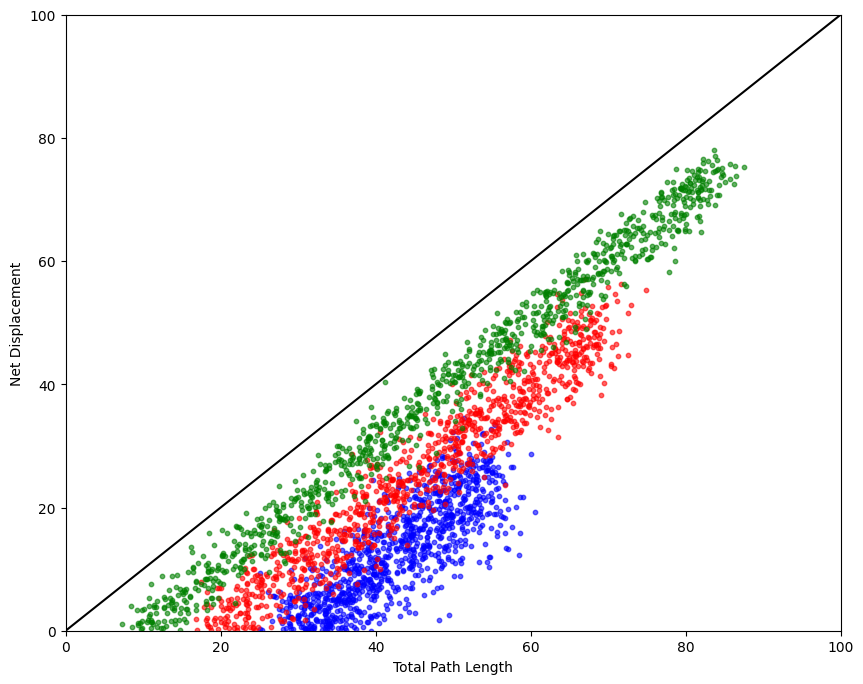

In [3]:
frac_lst = [0.25, 0.50, 0.75]
c_lst = ["b", "r", "g"]

# frac_lst = [1 / 3, 2 / 3]
# c_lst = ["r", "g"]

# frac_lst = [1 / 2]
# c_lst = ["g"]

xmax = 100
ymax = 100

plt.figure(figsize=(10, 8))
for frac, c in zip(frac_lst, c_lst):
    net, path, trajs = mixed_walk(
        n_particles=1000, n_steps=100, frac_det=frac, det_step_range=(-1, 1), rand_std=0.5, seed=0
    )
    m = np.sum(path * net) / np.sum(path**2)

    plt.scatter(path, net, alpha=0.6, c=c, s=10)
    # plt.plot([0, xmax], [0, ymax * m], c=c)

    print(frac, np.round(m, 3))

plt.plot([0, xmax], [0, ymax], c="k")

plt.xlabel("Total Path Length")
plt.ylabel("Net Displacement")

plt.xlim(0, xmax)
plt.ylim(0, ymax)

Intersection between frac_det=0.25 and frac_det=0.5: [0.477]
Intersection between frac_det=0.5 and frac_det=0.75: [0.727]


(0.0, 1.0)

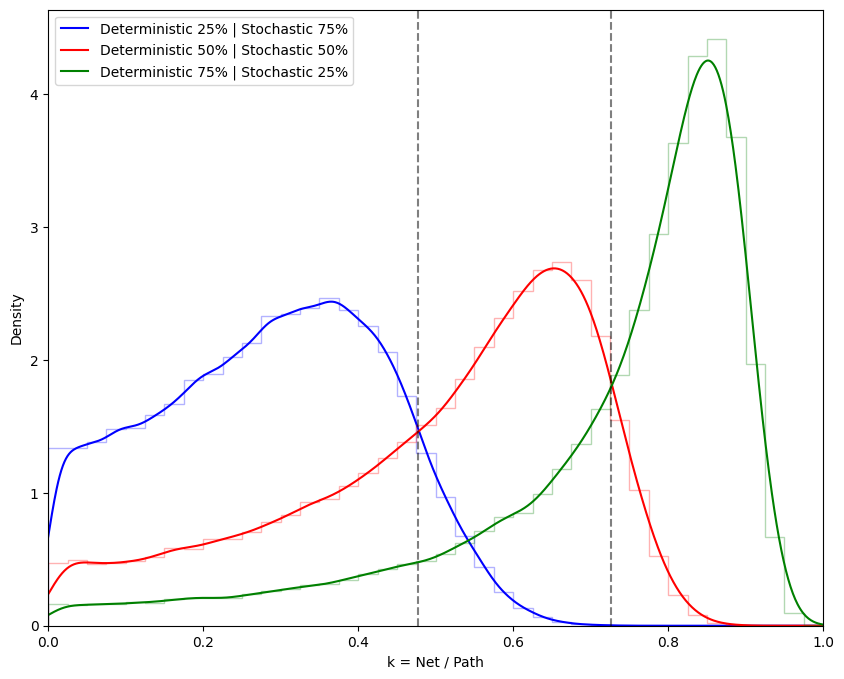

In [7]:
frac_lst = [0.25, 0.50, 0.75]
c_lst = ["b", "r", "g"]

bin_size = 0.025
bins = np.arange(0, 1 + bin_size, bin_size)
x_plot = np.linspace(0, 1, 1000)  # fine grid for smooth KDE

kdes = []

plt.figure(figsize=(10, 8))

# Compute KDEs first and plot
for frac, c in zip(frac_lst, c_lst):
    net, path, trajs = mixed_walk(
        n_particles=100000, n_steps=100, frac_det=frac, det_step_range=(-1, 1), rand_std=0.5, seed=0
    )
    k = net / path

    # Histogram (optional)
    plt.hist(k, bins, histtype="step", color=c, alpha=0.3, density=True)

    # Fit KDE
    kde = gaussian_kde(k)
    kde_vals = kde(x_plot)
    kdes.append(kde_vals)

    # Plot KDE
    # plt.plot(x_plot, kde_vals, color=c, label=str(int(frac * 100)) + "%" + " Deterministic")
    label = f"Deterministic {int(frac * 100)}% | Stochastic {int((1 - frac) * 100)}%"
    plt.plot(x_plot, kde_vals, color=c, label=label)

# Compute intersections between adjacent KDEs
for i in range(len(kdes) - 1):
    diff = kdes[i] - kdes[i + 1]
    # Find indices where the difference changes sign
    sign_changes = np.where(np.diff(np.sign(diff)))[0]
    intersections = x_plot[sign_changes]
    for x in intersections:
        plt.axvline(x, color="k", linestyle="--", alpha=0.5)
    print(
        f"Intersection between frac_det={frac_lst[i]} and frac_det={frac_lst[i + 1]}: {np.round(intersections, 3)}"
    )

plt.xlabel("k = Net / Path")
plt.ylabel("Density")
plt.legend()
plt.xlim(0, 1)

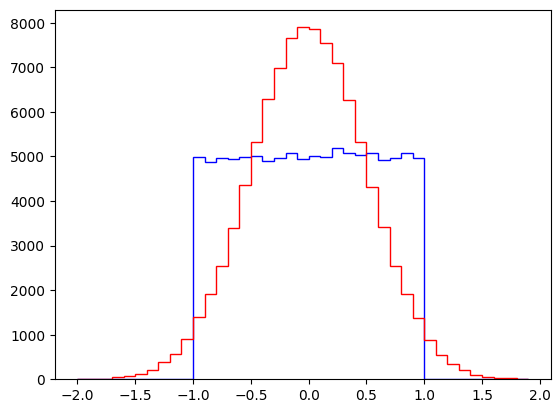

In [5]:
n_particles = 100000
det_step_range = (-1.0, 1.0)
deterministic_steps = np.random.uniform(det_step_range[0], det_step_range[1], n_particles)
bins = np.arange(-2, 2, 0.1)
plt.hist(deterministic_steps, histtype="step", bins=bins, color="b")

rand_std = 0.5
stochastic_steps = [np.random.normal(0, rand_std) for _ in range(0, n_particles)]
plt.hist(stochastic_steps, histtype="step", bins=bins, color="r")

plt.show()